Code to create visualisations, and maybe the dispersion relation of the inertial waves seen in mainly the wide FOV results.

* filtered & reconstructed contours
* frequency vs dispersion relation

Boiler Plate Code here

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding
Thesis plot settings applied


time shape
Filter Frequency = 0.3064Hz
Filter Frequency = 0.3064Hz
Filter Frequency = 0.169Hz
Filter Frequency = 0.1035Hz
(3599, 74, 119)


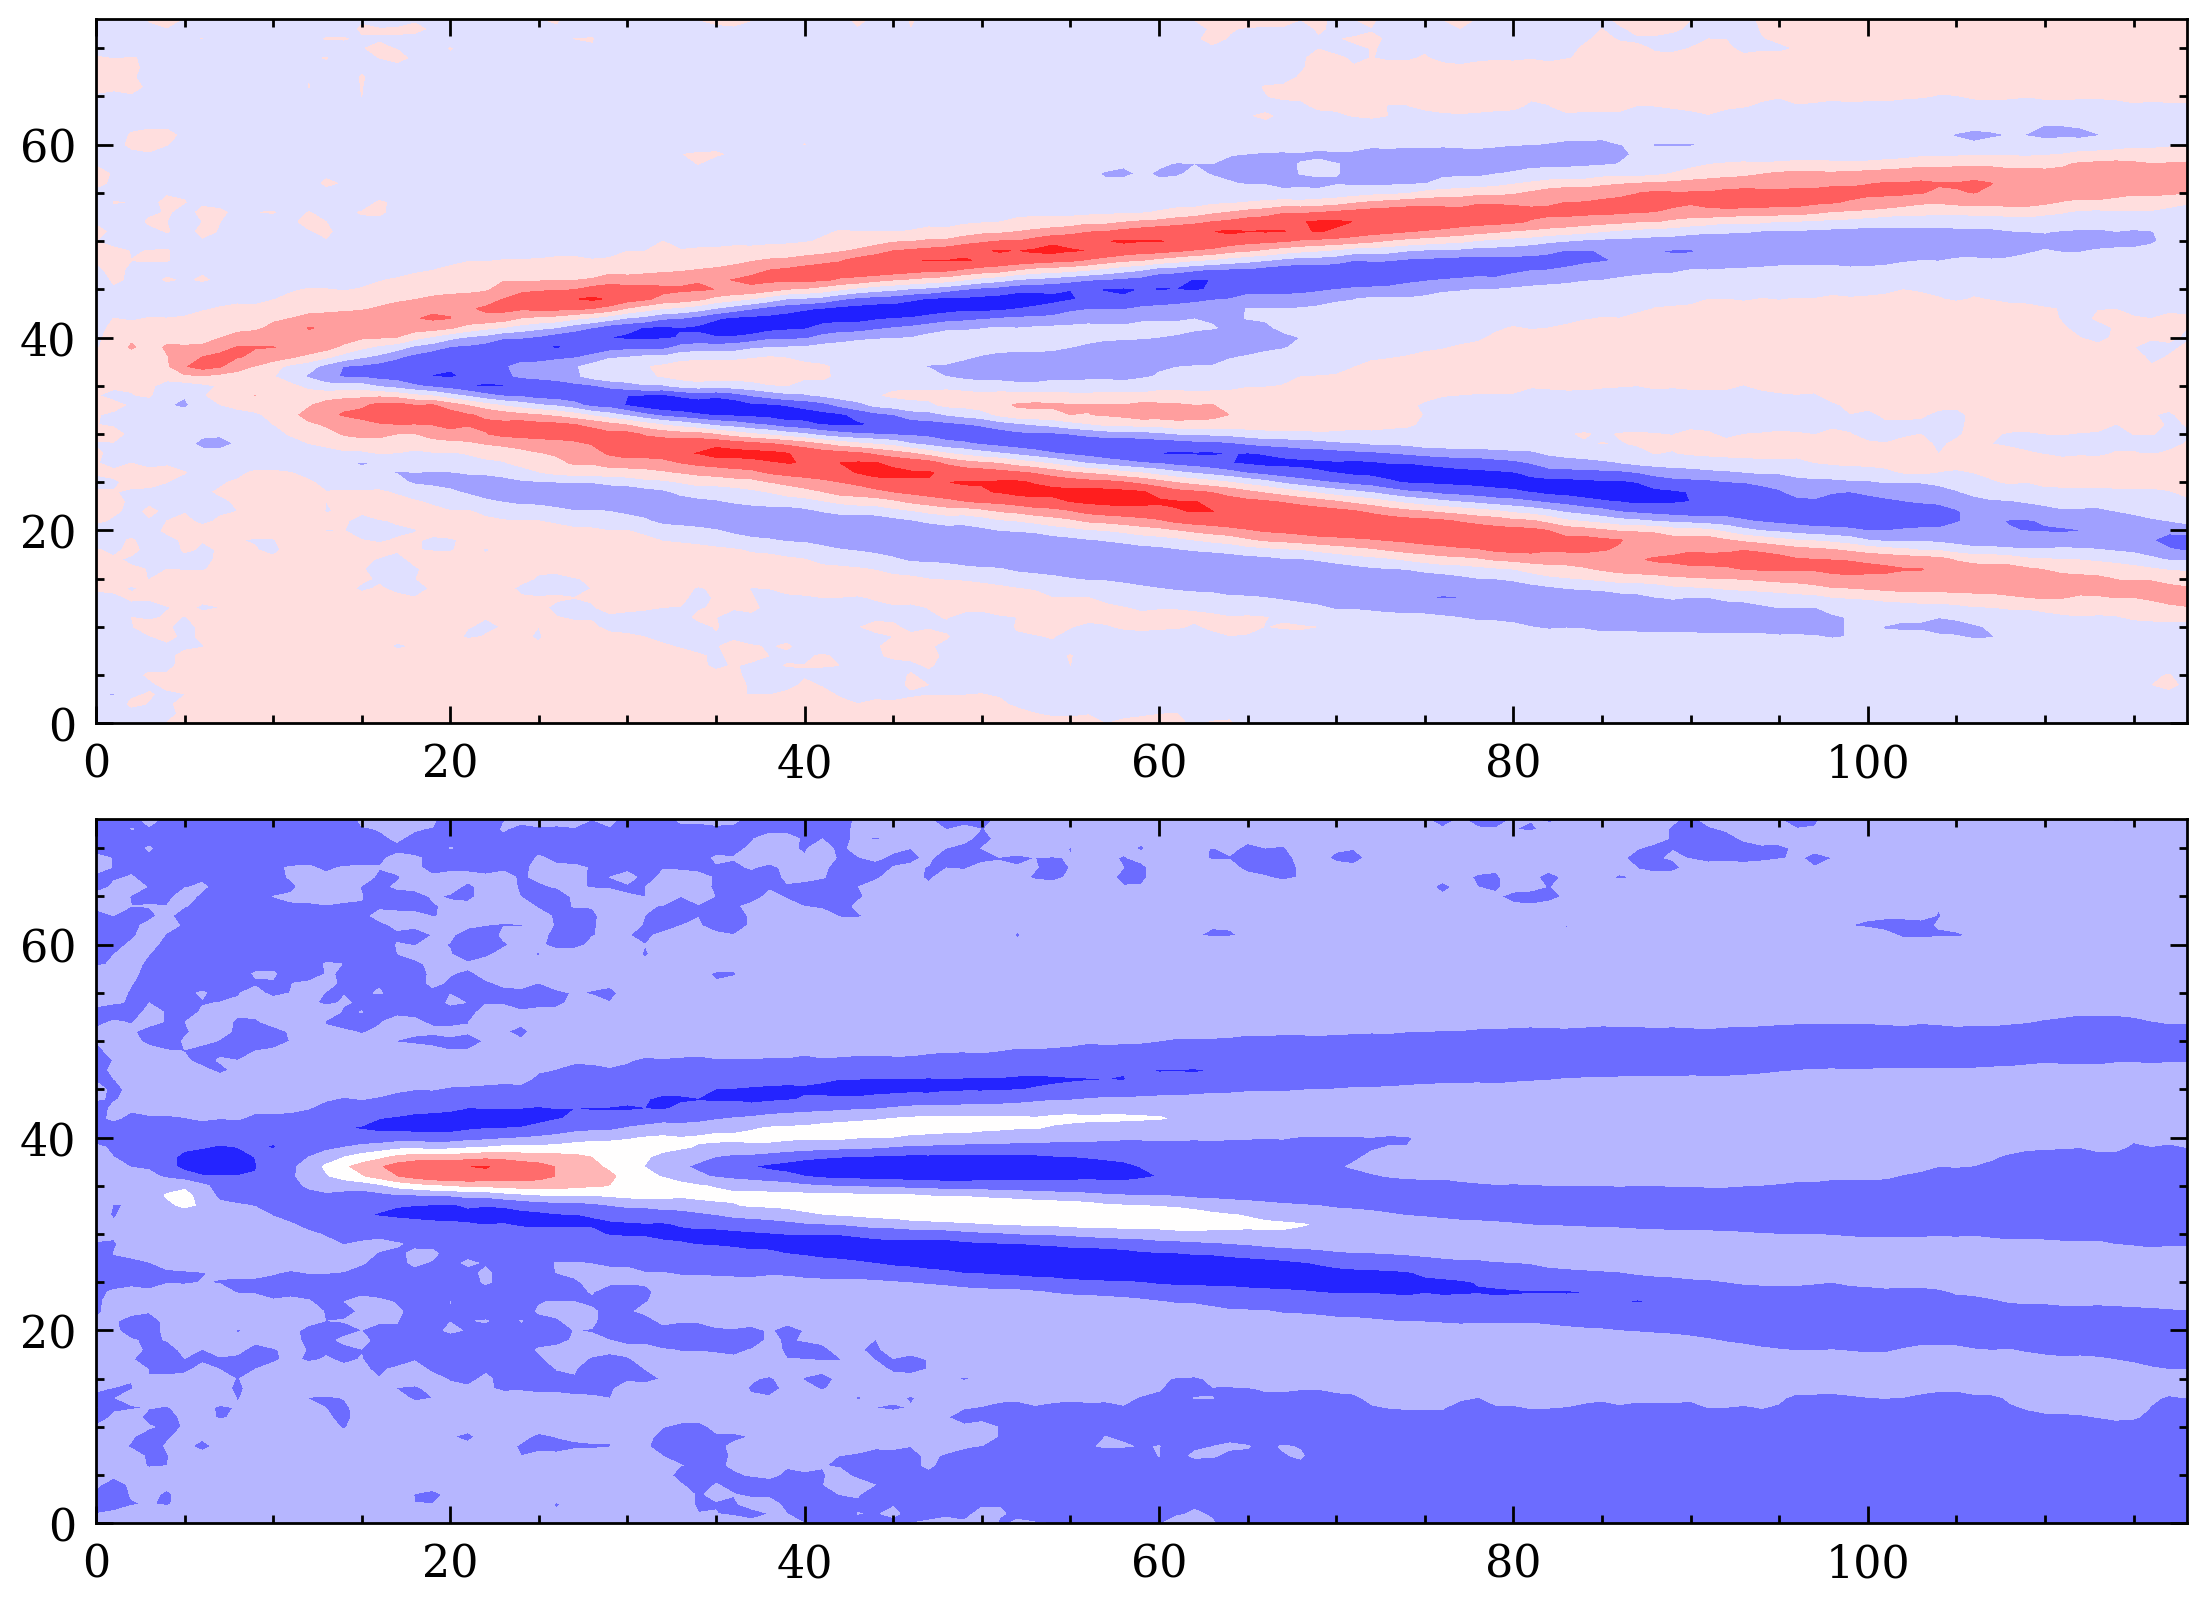

In [16]:
# h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')
# vels = h5file['3D0']['U100']['L100']['RPM12']

h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
vels = h5file['Wide']['U200']['L100']['RPM12']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
h5file.close()
u_gaussian, v_gaussian = gaussian_filter(u, sigma=0.7), gaussian_filter(v, sigma=0.7)
r_nd, z_nd = oj.NDUnitsForPlotsWide(u.shape[1], u.shape[2])

time = oj.frames_to_seconds(u, v, 60)
print("time shape")
# print(time.shape)

#### inertial wave image
vfft_u = oj.IWFilter(u, 40, 60, 12)
vfft_v = oj.IWFilter(v, 40, 60, 12)
# f1, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1)
# ax1.contourf(vfft_u[500,:,:], cmap="bwr")
# ax2.contourf(vfft_v[500,:,:], cmap="bwr")
# plt.show()


vfft_u  = oj.IWFilter(u, 65, 150, 12)
vfft_u2 = oj.IWFilter(u, 75, 150, 12)
print(vfft_u.shape)
f2, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1)
ax1.contourf(vfft_u [1500,:,:], cmap="bwr")
ax2.contourf(vfft_u2[1500,:,:], cmap="bwr")
plt.show()

# vfft_u = oj.IWFilter(u, 45, 60, 6)
# f2, ax1 = plt.subplots(nrows = 1, ncols = 1)
# ax1.contourf(vfft_u[500,:,:], cmap="bwr")
# plt.show()

Creating a proper series of plots.

These will be created individually and then put together in Latex

(3599, 74, 119)
(3599, 119, 74)
Filter Frequency = 0.169Hz


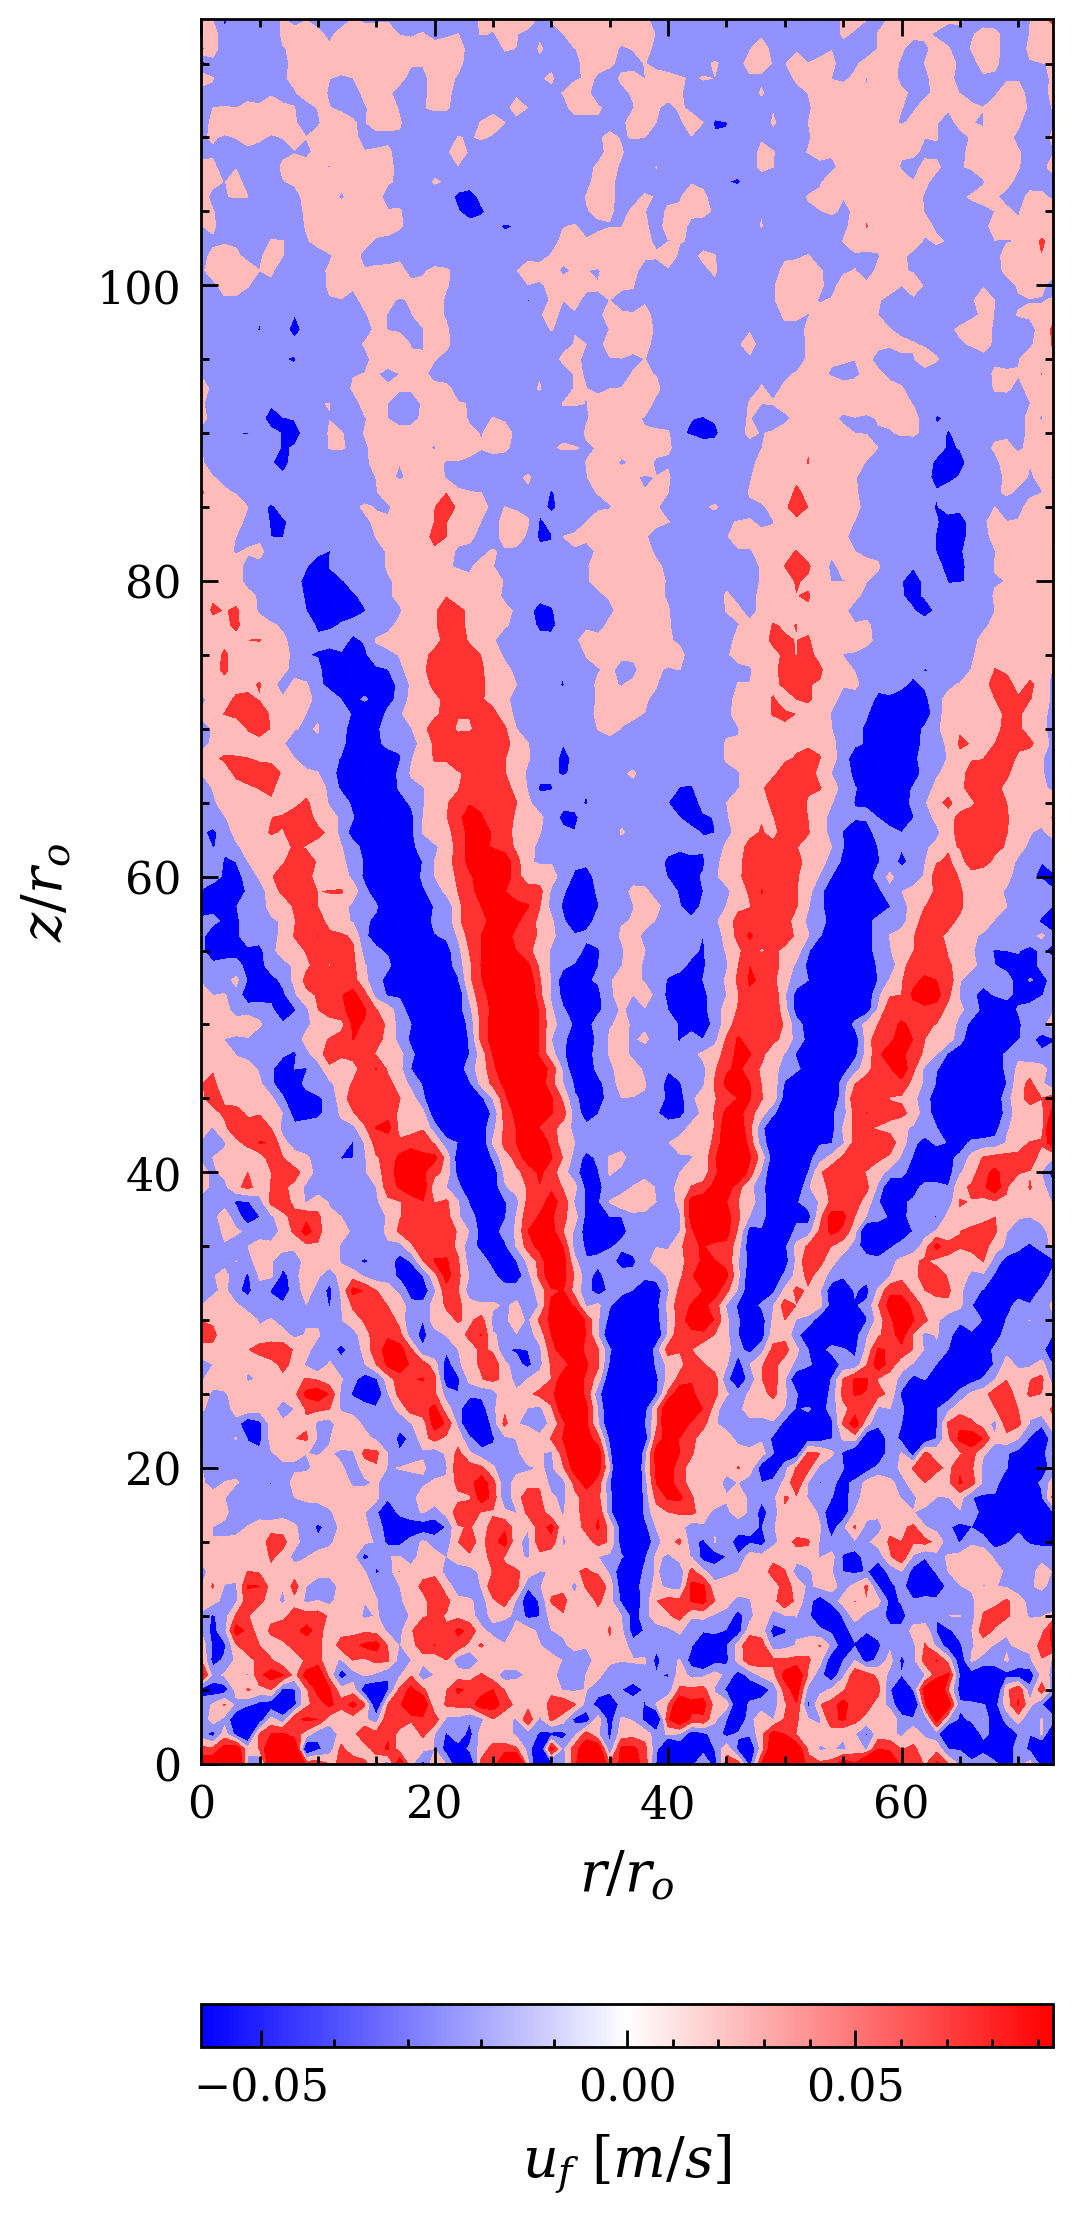

In [22]:
frame = 750

rpm = 12
fps = 60
angle = 65
print(u.shape)
print(u_swapped.shape)
u_swapped = np.transpose(u, (0, 2, 1))

vfft_u  = oj.IWFilter(u, angle, fps, rpm)

norm = colors.TwoSlopeNorm(vmin=np.min(vfft_u[frame, :, :]), vcenter=0, vmax=np.max(vfft_u[frame, :, :]))
f1, ax = plt.subplots(1, 1, figsize=(8/3, 5.5), layout='constrained')
# ax.contourf(r_nd, -z_nd, np.rot90(vfft_u[frame, :, :], 3), norm=norm, cmap='bwr', levels=10)
# ax.contourf(np.rot90(vfft_u[frame, :, :], 3), norm=norm, cmap='bwr', levels=10)
ax.contourf(u_swapped[frame, :, :], norm=norm, cmap='bwr', levels=10)
ax.set_xlabel(r"$r/r_{o}$")
ax.set_ylabel(r"$z/r_{o}$")
f1.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax, label=r'$u_{f} ~[m/s]$', location='bottom')